In [1]:
from datascience import *
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
plt.style.use('fivethirtyeight')

## 1/ Nearest neighbors

In [2]:
ckd = Table.read_table('../../Data/ChronicKidneyDisease.csv')
ckd

id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48,80,1.02,1,0,nan,normal,notpresent,notpresent,121,36,1.2,nan,nan,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7,50,1.02,4,0,nan,normal,notpresent,notpresent,nan,18,0.8,nan,nan,11.3,38,6000,nan,no,no,no,good,no,no,ckd
2,62,80,1.01,2,3,normal,normal,notpresent,notpresent,423,53,1.8,nan,nan,9.6,31,7500,nan,no,yes,no,poor,no,yes,ckd
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51,80,1.01,2,0,normal,normal,notpresent,notpresent,106,26,1.4,nan,nan,11.6,35,7300,4.6,no,no,no,good,no,no,ckd
5,60,90,1.015,3,0,nan,nan,notpresent,notpresent,74,25,1.1,142,3.2,12.2,39,7800,4.4,yes,yes,no,good,yes,no,ckd
6,68,70,1.01,0,0,nan,normal,notpresent,notpresent,100,54,24,104,4,12.4,36,nan,nan,no,no,no,good,no,no,ckd
7,24,nan,1.015,2,4,normal,abnormal,notpresent,notpresent,410,31,1.1,nan,nan,12.4,44,6900,5,no,yes,no,good,yes,no,ckd
8,52,100,1.015,3,0,normal,abnormal,present,notpresent,138,60,1.9,nan,nan,10.8,33,9600,4.0,yes,yes,no,good,no,yes,ckd
9,53,90,1.02,2,0,abnormal,abnormal,present,notpresent,70,107,7.2,114,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,ckd


In [3]:
def classifi(string):
    if string == 'ckd':
        return 1
    else:
        return 0
ckd = ckd.with_column( 
    'class' ,ckd.apply(classifi,'classification')
)
ckd

id,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification,class
0,48,80,1.02,1,0,nan,normal,notpresent,notpresent,121,36,1.2,nan,nan,15.4,44,7800,5.2,yes,yes,no,good,no,no,ckd,1
1,7,50,1.02,4,0,nan,normal,notpresent,notpresent,nan,18,0.8,nan,nan,11.3,38,6000,nan,no,no,no,good,no,no,ckd,1
2,62,80,1.01,2,3,normal,normal,notpresent,notpresent,423,53,1.8,nan,nan,9.6,31,7500,nan,no,yes,no,poor,no,yes,ckd,1
3,48,70,1.005,4,0,normal,abnormal,present,notpresent,117,56,3.8,111,2.5,11.2,32,6700,3.9,yes,no,no,poor,yes,yes,ckd,1
4,51,80,1.01,2,0,normal,normal,notpresent,notpresent,106,26,1.4,nan,nan,11.6,35,7300,4.6,no,no,no,good,no,no,ckd,1
5,60,90,1.015,3,0,nan,nan,notpresent,notpresent,74,25,1.1,142,3.2,12.2,39,7800,4.4,yes,yes,no,good,yes,no,ckd,1
6,68,70,1.01,0,0,nan,normal,notpresent,notpresent,100,54,24,104,4,12.4,36,nan,nan,no,no,no,good,no,no,ckd,1
7,24,nan,1.015,2,4,normal,abnormal,notpresent,notpresent,410,31,1.1,nan,nan,12.4,44,6900,5,no,yes,no,good,yes,no,ckd,1
8,52,100,1.015,3,0,normal,abnormal,present,notpresent,138,60,1.9,nan,nan,10.8,33,9600,4.0,yes,yes,no,good,no,yes,ckd,1
9,53,90,1.02,2,0,abnormal,abnormal,present,notpresent,70,107,7.2,114,3.7,9.5,29,12100,3.7,yes,yes,no,poor,no,yes,ckd,1


In [4]:
def standard_unit(array):
    return (array - np.mean(array))/np.std(array)

In [5]:
def clean_wc(x):
    x = str(x).strip()  # bỏ tab và khoảng trắng
    if x == '?':
        return np.nan
    return float(x)

wc = np.array([clean_wc(x) for x in ckd.column('wc')])
mask = ~np.isnan(wc)
ckd1 = ckd.where(mask)
mask1 = ~np.isnan(ckd1.column('hemo'))
ckd1 = ckd1.where(mask1)
mask2 = ~np.isnan(ckd1.column('bgr'))
ckd1 = ckd1.where(mask2)


ckd2 = Table().with_columns(
    'Hemoglobin', standard_unit(ckd1.column('hemo')),
    'Glucose', standard_unit(ckd1.column('bgr')),
    'White Blood Cell Count', standard_unit(ckd1.column('wc').astype(float)),
    'Class', ckd1.column('class')        
)
ckd2

Hemoglobin,Glucose,White Blood Cell Count,Class
0.83448,-0.284472,-0.218277,1
-1.16476,3.57717,-0.321034,1
-0.613245,-0.33562,-0.595052,1
-0.475366,-0.476276,-0.389538,1
-0.268549,-0.885456,-0.218277,1
-0.199609,3.41094,-0.526548,1
-0.751123,-0.0670948,0.398264,1
-1.19923,-0.936604,1.25457,1
-0.751123,3.02734,-1.3486,1
-1.13029,0.827988,1.28882,1


class | id   | age  | bp   | sg    | al   | su   | rbc    | pc       | pcc        | ba         | bgr  | bu   | sc   | sod  | pot  | hemo | pcv  | wc    | rc   | htn  | dm   | cad  | appet | pe   | ane  | classification | color
0     | 37   | 72   | 80   | nan   | nan  | nan  | nan    | nan      | notpresent | notpresent | 137  | 65   | 3.4  | 141  | 4.7  | 9.7  | 28   | 6900  | 2.5  | yes  | yes  | no   | poor  | no   | yes  | ckd	           | gold
0     | 230  | 65   | 60   | 1.01  | 2    | 0    | normal | abnormal | present    | notpresent | 192  | 17   | 1.7  | 130  | 4.3  | nan  | nan  | 9500  | nan  | yes  | yes  | no   | poor  | no   | no   | ckd	           | gold
0     | 250  | 40   | 80   | 1.025 | 0    | 0    | normal | normal   | notpresent | notpresent | 140  | 10   | 1.2  | 135  | 5    | 15   | 48   | 10400 | 4.5  | no   | no   | no   | good  | no   | no   | notckd         | gold
0     | 251  | 23   | 80   | 1.025 | 0    | 0    | normal | normal   | notpresent | notpresent 

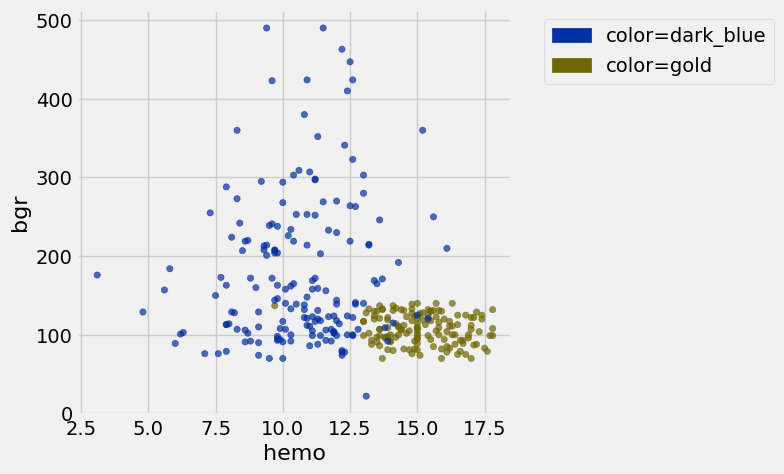

In [6]:
color_table =Table().with_columns(
    'class', make_array(1,0),
    'color', make_array('dark_blue','gold')
)
ckd = ckd.join('class', color_table)
print(ckd)
ckd.scatter('hemo','bgr',group = 'color')

In [7]:
ckd = ckd.sort('class',descending= False)
print(ckd)
ckd.row(0)

class | id   | age  | bp   | sg    | al   | su   | rbc    | pc       | pcc        | ba         | bgr  | bu   | sc   | sod  | pot  | hemo | pcv  | wc    | rc   | htn  | dm   | cad  | appet | pe   | ane  | classification | color
0     | 37   | 72   | 80   | nan   | nan  | nan  | nan    | nan      | notpresent | notpresent | 137  | 65   | 3.4  | 141  | 4.7  | 9.7  | 28   | 6900  | 2.5  | yes  | yes  | no   | poor  | no   | yes  | ckd	           | gold
0     | 230  | 65   | 60   | 1.01  | 2    | 0    | normal | abnormal | present    | notpresent | 192  | 17   | 1.7  | 130  | 4.3  | nan  | nan  | 9500  | nan  | yes  | yes  | no   | poor  | no   | no   | ckd	           | gold
0     | 250  | 40   | 80   | 1.025 | 0    | 0    | normal | normal   | notpresent | notpresent | 140  | 10   | 1.2  | 135  | 5    | 15   | 48   | 10400 | 4.5  | no   | no   | no   | good  | no   | no   | notckd         | gold
0     | 251  | 23   | 80   | 1.025 | 0    | 0    | normal | normal   | notpresent | notpresent 

Row(class=0, id=37, age=72.0, bp=80.0, sg=nan, al=nan, su=nan, rbc='nan', pc='nan', pcc='notpresent', ba='notpresent', bgr=137.0, bu=65.0, sc=3.3999999999999999, sod=141.0, pot=4.7000000000000002, hemo=9.6999999999999993, pcv='28', wc='6900', rc='2.5', htn='yes', dm='yes', cad='no', appet='poor', pe='no', ane='yes', classification='ckd\t', color='gold')

In [8]:
mask = ~np.isnan(ckd.column('hemo')) & ~np.isnan(ckd.column('bgr'))
ckd_clear = ckd.where(mask)


ckd3 = Table().with_columns(
    'Hemoglobin', standard_unit(ckd_clear.column('hemo')),
    'Glucose', standard_unit(ckd_clear.column('bgr')),
    'class', ckd_clear.column('class')
)
ckd3 = ckd3.join('class',color_table)
ckd3    

class,Hemoglobin,Glucose,color
0,-1.02345,-0.123788,gold
0,0.817093,-0.0858742,gold
0,1.51164,-0.97054,gold
0,1.12964,-0.818883,gold
0,0.956002,-0.351274,gold
0,0.122547,-0.604036,gold
0,0.330911,-0.325998,gold
0,0.643457,-0.199617,gold
0,0.46982,-0.705141,gold
0,0.435093,-0.616674,gold


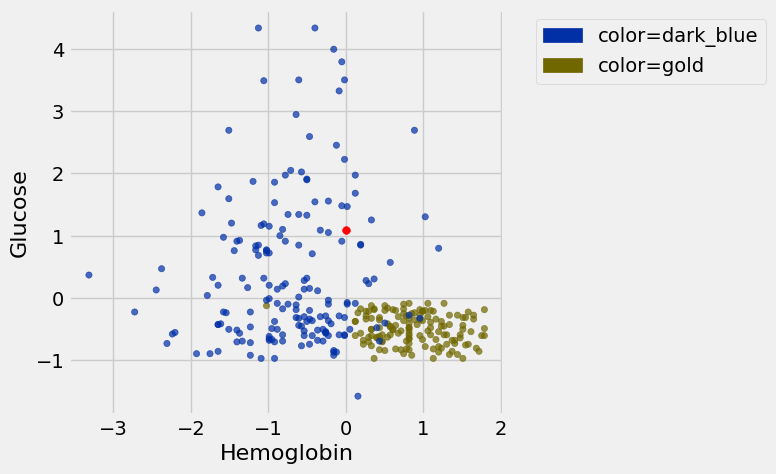

In [9]:
alice = make_array(0, 1.1)
ckd3.scatter('Hemoglobin','Glucose', group = 'color')
plt.scatter(alice.item(0),alice.item(1), color = 'red', s = 30)


In [10]:
def distance(point1,point2):
    return np.sqrt(np.sum((point1 - point2)**2))
def max_abs(row):
    return np.max(np.abs(np.array(row)))

Xay dung thu K-NN voi diem alice(0,1.1) gan 5 diem nhat

In [11]:
def distance_from_alice(row):
    return distance(alice, np.array(row))
ckd_attributes = ckd3.select('Hemoglobin','Glucose')
ckd_attributes

Hemoglobin,Glucose
-1.02345,-0.123788
0.817093,-0.0858742
1.51164,-0.97054
1.12964,-0.818883
0.956002,-0.351274
0.122547,-0.604036
0.330911,-0.325998
0.643457,-0.199617
0.46982,-0.705141
0.435093,-0.616674


In [12]:
ckd3 = ckd3.with_column(
    'diatance from alice', ckd_attributes.apply(distance_from_alice)
)
ckd3

class,Hemoglobin,Glucose,color,diatance from alice
0,-1.02345,-0.123788,gold,1.59534
0,0.817093,-0.0858742,gold,1.44012
0,1.51164,-0.97054,gold,2.56363
0,1.12964,-0.818883,gold,2.2267
0,0.956002,-0.351274,gold,1.73785
0,0.122547,-0.604036,gold,1.70844
0,0.330911,-0.325998,gold,1.46389
0,0.643457,-0.199617,gold,1.45019
0,0.46982,-0.705141,gold,1.86528
0,0.435093,-0.616674,gold,1.77095


In [13]:
ckd3 = ckd3.sort('diatance from alice', descending= False)

In [14]:
ckd3.take(np.arange(5))

class,Hemoglobin,Glucose,color,diatance from alice
1,-0.0510892,0.912535,dark_blue,0.194302
1,-0.224726,1.05155,dark_blue,0.229888
1,0.192002,0.861982,dark_blue,0.305806
1,0.192002,0.849344,dark_blue,0.315742
1,-0.328908,1.08947,dark_blue,0.329076


Trien khai bo phan loai voi nhieu thuoc tinh


In [15]:
banknotes = Table.read_table('../../Data/banknote-authentication.csv')
banknotes

variance,skew,curtosis,entropy,class
3.6216,8.6661,-2.8073,-0.44699,0
4.5459,8.1674,-2.4586,-1.4621,0
3.866,-2.6383,1.9242,0.10645,0
3.4566,9.5228,-4.0112,-3.5944,0
0.32924,-4.4552,4.5718,-0.9888,0
4.3684,9.6718,-3.9606,-3.1625,0
3.5912,3.0129,0.72888,0.56421,0
2.0922,-6.81,8.4636,-0.60216,0
3.2032,5.7588,-0.75345,-0.61251,0
1.5356,9.1772,-2.2718,-0.73535,0


In [16]:
color_table = Table().with_columns(
    'class',make_array(1,0),
    'color',make_array('darkblue','gold')
)
banknotes = banknotes.join('class',color_table)
banknotes

class,variance,skew,curtosis,entropy,color
0,3.6216,8.6661,-2.8073,-0.44699,gold
0,4.5459,8.1674,-2.4586,-1.4621,gold
0,3.866,-2.6383,1.9242,0.10645,gold
0,3.4566,9.5228,-4.0112,-3.5944,gold
0,0.32924,-4.4552,4.5718,-0.9888,gold
0,4.3684,9.6718,-3.9606,-3.1625,gold
0,3.5912,3.0129,0.72888,0.56421,gold
0,2.0922,-6.81,8.4636,-0.60216,gold
0,3.2032,5.7588,-0.75345,-0.61251,gold
0,1.5356,9.1772,-2.2718,-0.73535,gold


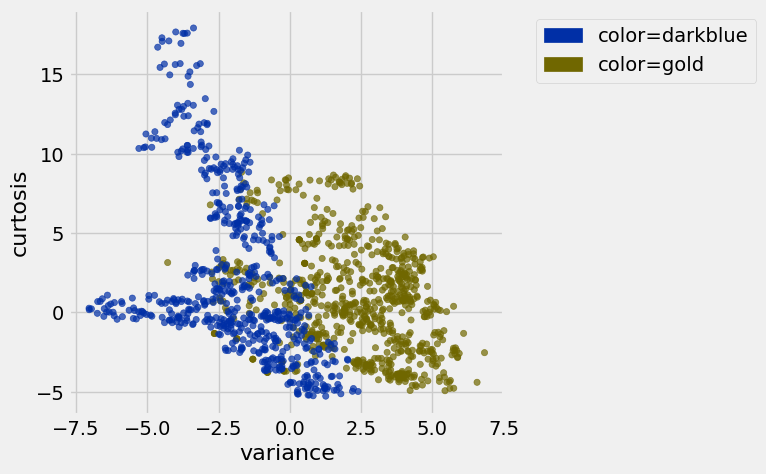

In [17]:
banknotes.scatter('variance','curtosis',group = 'color')

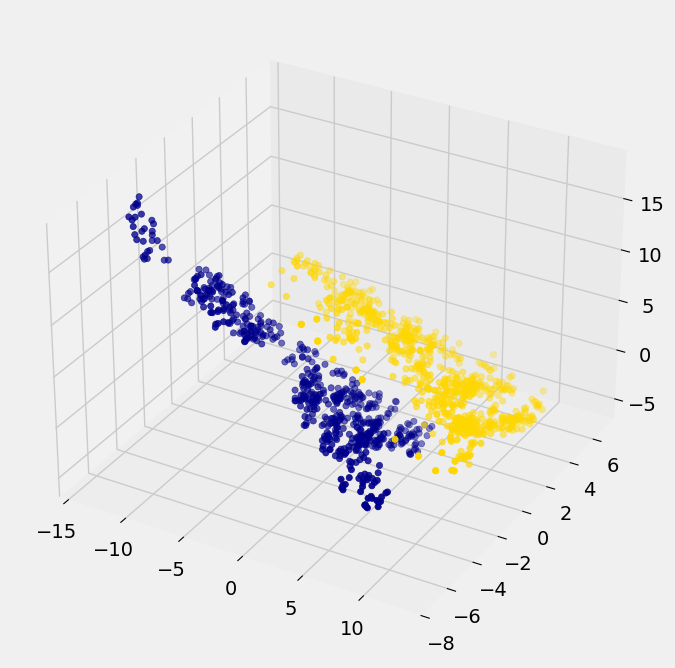

In [18]:
ax = plt.figure(figsize=(8,8)).add_subplot(111,projection = '3d')
ax.scatter(banknotes.column('skew'),
           banknotes.column('variance'),
           banknotes.column('curtosis'),
           color = banknotes.column('color')
           )

In [ ]:
def distance(point1,point2):
    return np.sqrt(np.sum((point1 - point2)**2))

k_NN voi nhieu thuoc tinh

In [19]:
wine = Table.read_table('../../Data/wine.csv')
wine

Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.2,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.4,1050
1,13.16,2.36,2.67,18.6,101,2.8,3.24,0.3,2.81,5.68,1.03,3.17,1185
1,14.37,1.95,2.5,16.8,113,3.85,3.49,0.24,2.18,7.8,0.86,3.45,1480
1,13.24,2.59,2.87,21,118,2.8,2.69,0.39,1.82,4.32,1.04,2.93,735
1,14.2,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
1,14.39,1.87,2.45,14.6,96,2.5,2.52,0.3,1.98,5.25,1.02,3.58,1290
1,14.06,2.15,2.61,17.6,121,2.6,2.51,0.31,1.25,5.05,1.06,3.58,1295
1,14.83,1.64,2.17,14,97,2.8,2.98,0.29,1.98,5.2,1.08,2.85,1045
1,13.86,1.35,2.27,16,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [21]:
def is_x(x):
    if x == 1:
        return 1
    else:
        return 0
wine = wine.with_column('class',wine.apply(is_x,'Wine'))
wine

Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline,class
1,14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.2,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.4,1050,1
1,13.16,2.36,2.67,18.6,101,2.8,3.24,0.3,2.81,5.68,1.03,3.17,1185,1
1,14.37,1.95,2.5,16.8,113,3.85,3.49,0.24,2.18,7.8,0.86,3.45,1480,1
1,13.24,2.59,2.87,21,118,2.8,2.69,0.39,1.82,4.32,1.04,2.93,735,1
1,14.2,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,1
1,14.39,1.87,2.45,14.6,96,2.5,2.52,0.3,1.98,5.25,1.02,3.58,1290,1
1,14.06,2.15,2.61,17.6,121,2.6,2.51,0.31,1.25,5.05,1.06,3.58,1295,1
1,14.83,1.64,2.17,14,97,2.8,2.98,0.29,1.98,5.2,1.08,2.85,1045,1
1,13.86,1.35,2.27,16,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045,1


In [22]:
wine_attributes = wine.drop('Wine')
wine_attributes

Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline,class
14.23,1.71,2.43,15.6,127,2.8,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
13.2,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.4,1050,1
13.16,2.36,2.67,18.6,101,2.8,3.24,0.3,2.81,5.68,1.03,3.17,1185,1
14.37,1.95,2.5,16.8,113,3.85,3.49,0.24,2.18,7.8,0.86,3.45,1480,1
13.24,2.59,2.87,21,118,2.8,2.69,0.39,1.82,4.32,1.04,2.93,735,1
14.2,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450,1
14.39,1.87,2.45,14.6,96,2.5,2.52,0.3,1.98,5.25,1.02,3.58,1290,1
14.06,2.15,2.61,17.6,121,2.6,2.51,0.31,1.25,5.05,1.06,3.58,1295,1
14.83,1.64,2.17,14,97,2.8,2.98,0.29,1.98,5.2,1.08,2.85,1045,1
13.86,1.35,2.27,16,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045,1


In [34]:
def all_distances(training, new_point):
    attribute = training.drop('Wine')
    def distance_from_newpoint(row):
        return distance(np.array(row),new_point)
    return attribute.apply(distance_from_newpoint)
def table_with_distance(training, new_point):
    return training.with_column('distances',all_distances(training,new_point))
def closet(training, new_point,k):
    result = table_with_distance(training,new_point)
    sort_k = result.sort('distances', descending = False)
    return sort_k.take(np.arange(k))

In [56]:
def majority(topkclasses):
    ones = topkclasses.where('class',are.equal_to(1)).num_rows
    zeros = topkclasses.where('class',are.equal_to(0)).num_rows
    if ones > zeros:
        return 1
    else:
        return 0

def classify(training, new_point,k):
    closetk = closet(training,new_point,k)
    topkclasses = closetk
    return majority(topkclasses)
classify(wine,wine.drop('Wine').row(170),5)

0

5.accuracy of classifier

In [81]:
shuffle_wine = wine.sample(with_replacement= False)
training_set = shuffle_wine.take(np.arange(89))
testing_set = shuffle_wine.take(np.arange(89,178))


In [ ]:
def count_zero(array):
    return len(array) - np.count_nonzero(array)
def count_equal(array1,array2):
    return count_zero(array1-array2)
def evaluate_accuracy(training,test,k):
    test_attributes = test.drop('class')
    def classify_testrow(row):
        return classify(training,row,k)
    c = test_attributes.apply(classify_testrow)
    return count_equal(c,test.column('class'))/test.num_rows
evaluate_accuracy(training_set,testing_set,5)   

0.7303370786516854

## 6. Multiple Regression

In [83]:
all_sales = Table.read_table('../../Data/house.csv')
sales = all_sales.where('Bldg Type', '1Fam').where('Sale Condition', 'Normal').select(
    'SalePrice', '1st Flr SF', '2nd Flr SF', 
    'Total Bsmt SF', 'Garage Area', 
    'Wood Deck SF', 'Open Porch SF', 'Lot Area', 
    'Year Built', 'Yr Sold')
sales.sort('SalePrice')

SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Wood Deck SF,Open Porch SF,Lot Area,Year Built,Yr Sold
35000,498,0,498,216,0,0,8088,1922,2006
39300,334,0,0,0,0,0,5000,1946,2007
40000,649,668,649,250,0,54,8500,1920,2008
45000,612,0,0,308,0,0,5925,1940,2009
52000,729,0,270,0,0,0,4130,1935,2008
52500,693,0,693,0,0,20,4118,1941,2006
55000,723,363,723,400,0,24,11340,1920,2008
55000,796,0,796,0,0,0,3636,1922,2008
57625,810,0,0,280,119,24,21780,1910,2009
58500,864,0,864,200,0,0,8212,1914,2010


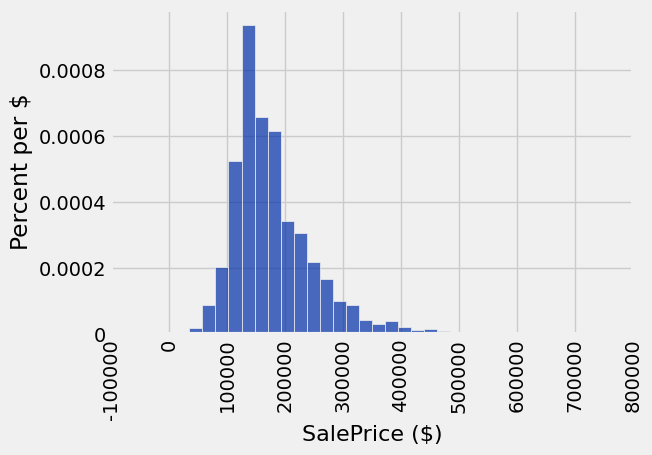

In [84]:
sales.hist('SalePrice', bins = 32,unit = '$')

In [85]:
def correlation(table,x,y):
    return np.mean(standard_unit(table.column(x)) * standard_unit(table.column(y)))
for i in sales.labels:
    print('Corelation of ',i,' and SalePrice: ',correlation(sales,i,'SalePrice')) 

Corelation of  SalePrice  and SalePrice:  1.0
Corelation of  1st Flr SF  and SalePrice:  0.642466254103
Corelation of  2nd Flr SF  and SalePrice:  0.35752189428
Corelation of  Total Bsmt SF  and SalePrice:  0.652978626757
Corelation of  Garage Area  and SalePrice:  0.638594485252
Corelation of  Wood Deck SF  and SalePrice:  0.352698666195
Corelation of  Open Porch SF  and SalePrice:  0.336909417026
Corelation of  Lot Area  and SalePrice:  0.290823455116
Corelation of  Year Built  and SalePrice:  0.565164753714
Corelation of  Yr Sold  and SalePrice:  0.0259485790807


In [89]:
train, test = sales.split(1001)
print(train.num_rows, 'training and', test.num_rows, 'test instances.')

1001 training and 1001 test instances.


In [93]:
def slope(t,label_1,label_2):
    return correlation(t,label_1,label_2) * np.std(t.column(label_2))/np.std(t.column(label_1))

def intercept(t,label_1,label_2):
    return np.mean(t.column(label_2)) - slope(t,label_1,label_2) * np.mean(t.column(label_1))

In [94]:
def predict(slopes,row):
    return np.sum(slopes * np.array(row))

In [91]:
train_prices = train.column(0)
train_attributes = train.drop(0)

def rmse(slopes,attributes,prices):
    error = []
    for i in np.arange(len(prices)):
        predicted = predict(slopes,attributes.row(i))
        error.append((prices.item(i) -predicted)**2)
    return np.mean(error)**0.5

def rmse_train(slopes):
    return rmse(slopes,train_attributes,train_prices)

In [96]:
example_slopes = np.random.normal(10, 1, len(train_attributes))
best_slope = minimize(rmse_train,start = example_slopes, array = True, smooth= True)
rmse_train(best_slope)

30210.101401740125

In [112]:
test_price = test.column(0)
test_attributes = test.drop(0)
rmse_linear = rmse(best_slope,test_attributes,test_price)
rmse_linear

32206.294559784164

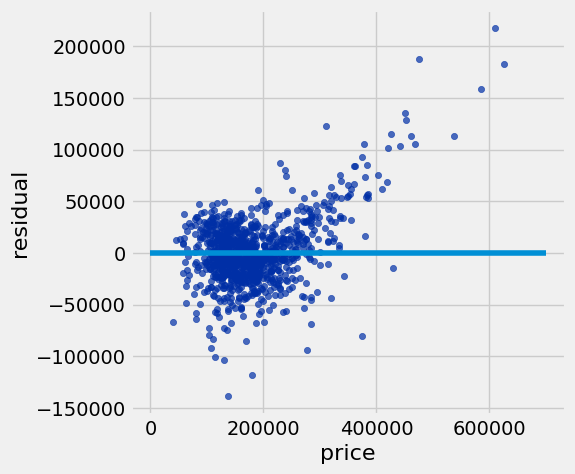

In [99]:
def test_predict(row):
    return predict(best_slope,row)
Residual = Table().with_columns('price',test_price,'residual',test_price - test_attributes.apply(test_predict)).scatter(0,'residual')
plt.plot([0,7e5],[0,0])

K-NN for regression

In [103]:
train_nn = train.select(0, 1, 2, 3, 4, 8)
test_nn = test.select(0, 1, 2, 3, 4, 8)
train_nn.show(3)

SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Year Built
147000,1143,0,1143,0,2006
137000,628,600,600,215,1918
128000,841,806,806,216,1915


In [111]:
def row_distance(row1,row2):
    return distance(np.array(row1),np.array(row2))

def closetk(training,example_row,k,price):
    dist = []
    train_attributes = training.drop(price)
    for row in train_attributes.rows:
        dist.append(row_distance(example_row,row))
    return training.with_column('distance',dist).sort('distance',descending = False).take(np.arange(k))
closetk(test_nn,test_nn.drop(0).row(0),5,'SalePrice')
    

SalePrice,1st Flr SF,2nd Flr SF,Total Bsmt SF,Garage Area,Year Built,distance
148500,1002,0,1002,902,1970,0
169900,1034,0,1012,888,1976,36.8239
137500,964,0,964,784,1961,129.973
144000,904,0,864,912,1970,169.552
145000,1040,0,1040,686,1968,222.594


In [109]:
def predict_nn(example):
    return np.average(closetk(train_nn,example,5,'SalePrice').column('SalePrice'))


In [110]:
print(test_nn.column(0).item(0))
predict_nn(test_nn.drop(0).row(0))

148500


132900.0

In [114]:
nn_test_predictions = test_nn.drop(0).apply(predict_nn)
nn_test_rmse = np.sqrt(np.mean((test_nn.column(0) - nn_test_predictions)**2))
print(nn_test_rmse)
rmse_linear

33731.801564


32206.294559784164

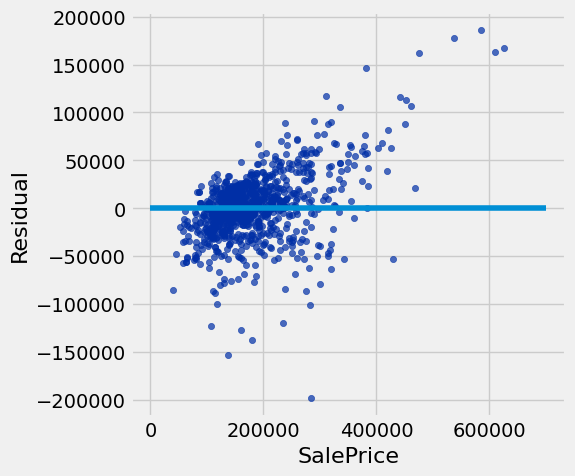

In [117]:
Residual = test_nn.with_column('Residual',test.column('SalePrice') - nn_test_predictions).scatter('SalePrice','Residual')
plt.plot([0,7e5],[0,0])